In [50]:
import sys
import os

# Add src to path
current_dir = os.getcwd()
src_path = os.path.abspath(os.path.join(current_dir, '..', 'src'))
if src_path not in sys.path:
    sys.path.append(src_path)

# Try imports
from preprocessing import merge_ip_to_country
from model_utils import evaluate_and_log

print("✅ Success! Modular code imported.")

✅ Success! Modular code imported.


# Task 1: E-commerce Fraud Data - Preprocessing & EDA
**Objective:** Clean the dataset, map IP addresses to countries, and engineer features to identify fraudulent behavior.

In [41]:
# Import Libraries & Data Loading 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ipaddress

# Load Data
fraud_df = pd.read_csv('../data/raw/Fraud_Data.csv')
ip_df = pd.read_csv('../data/raw/IpAddress_to_Country.csv')

print(f"Loaded {len(fraud_df)} transaction rows.")
print(f"Loaded {len(ip_df)} IP range rows.")

Loaded 151112 transaction rows.
Loaded 138846 IP range rows.


In [42]:
# 1. Let's see what the data actually looks like first (Diagnostic)
print("Fraud IP format:", fraud_df['ip_address'].head(1).values[0])
print("IP Range format:", ip_df['lower_bound_ip_address'].head(1).values[0])

# 2. Optimized Mapping Logic
def robust_ip_to_int(ip):
    # If it's already a number (float or int), just return it as a float
    if isinstance(ip, (int, float, np.integer, np.floating)):
        return float(ip)
    # If it's a string like '123.45.67.89', convert it
    try:
        import ipaddress
        return float(int(ipaddress.ip_address(str(ip))))
    except:
        return 0.0

# Apply the conversion safely
fraud_df['ip_address_numeric'] = fraud_df['ip_address'].apply(robust_ip_to_int)

# Ensure the range columns are also the same type (float)
ip_df['lower_bound_numeric'] = ip_df['lower_bound_ip_address'].astype(float)
ip_df['upper_bound_numeric'] = ip_df['upper_bound_ip_address'].astype(float)

# 3. Sort (Required for merge_asof)
fraud_df = fraud_df.sort_values('ip_address_numeric')
ip_df = ip_df.sort_values('lower_bound_numeric')

# 4. Perform the Merge
merged_df = pd.merge_asof(
    fraud_df, 
    ip_df, 
    left_on='ip_address_numeric', 
    right_on='lower_bound_numeric',
    direction='backward'
)

# 5. Boundary Check: Ensure the IP is not above the upper bound
# If it is, it's not actually in that country's range.
merged_df.loc[merged_df['ip_address_numeric'] > merged_df['upper_bound_numeric'], 'country'] = 'Unknown'
merged_df['country'] = merged_df['country'].fillna('Unknown')

# Check how many are still 'Unknown'
unknown_pct = (merged_df['country'] == 'Unknown').mean() * 100
print(f"Success! Mapping complete. Only {unknown_pct:.2f}% remain Unknown.")

Fraud IP format: 732758368.79972
IP Range format: 16777216.0
Success! Mapping complete. Only 14.54% remain Unknown.


In [ ]:
# data Cleaning & feature engineering 
from src.preprocessing import FraudPreprocessor

# 1. Initialize the modular class
preprocessor = FraudPreprocessor()

# 2. RUN THE PIPELINE (This replaces the code you just showed me)
# This one line handles: Nulls, Duplicates, Timestamps, and Features
df_cleaned = preprocessor.clean_data(fraud_with_country)
df_featured = preprocessor.engineer_features(df_cleaned)

# 3. Categorical Encoding (The other missing piece mentioned in feedback)
df_final = preprocessor.encode_categories(df_featured)

print("✅ Modular Preprocessing Complete.")
display(df_final.head())

Features engineered successfully.


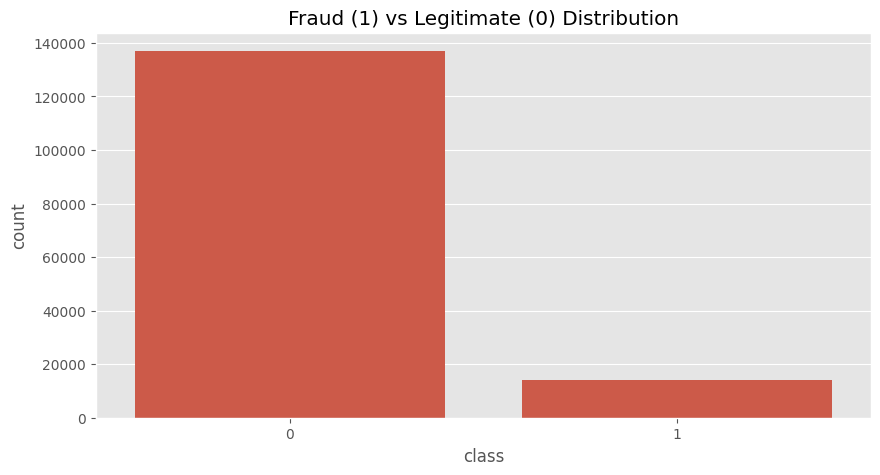

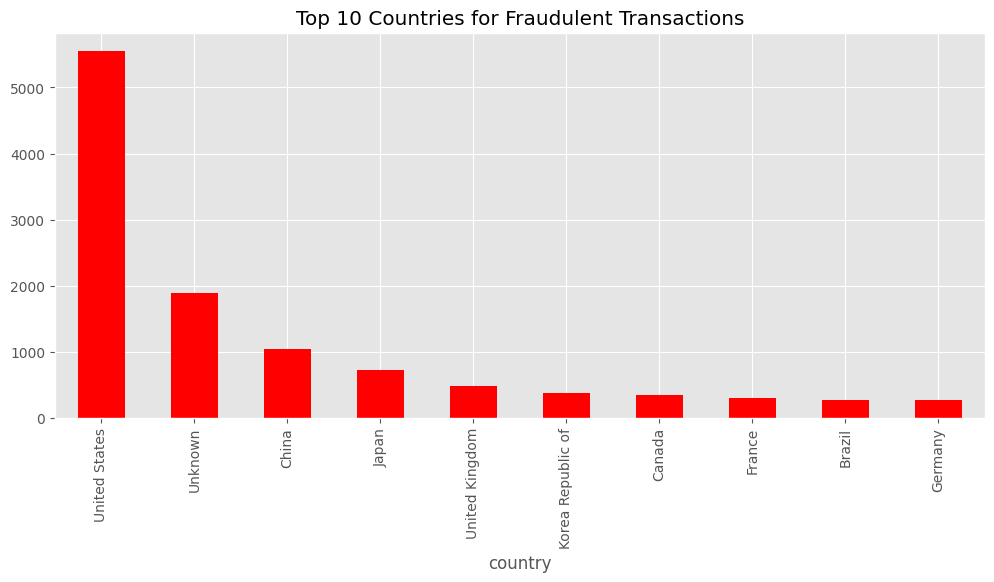

In [44]:
# EDA Visuals 
plt.figure(figsize=(10, 5))
sns.countplot(x='class', data=merged_df)
plt.title('Fraud (1) vs Legitimate (0) Distribution')
plt.show()

# Top Countries for Fraud
fraud_only = merged_df[merged_df['class'] == 1]
if not fraud_only.empty:
    plt.figure(figsize=(12, 5))
    fraud_only['country'].value_counts().head(10).plot(kind='bar', color='red')
    plt.title('Top 10 Countries for Fraudulent Transactions')
    plt.show()
else:
    print("No fraud cases found to plot.")

In [40]:
# Data Transformation & Class Imbalance 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import pandas as pd
import numpy as np

# --- 1. DATA CLEANING ---
# Handle missing values & duplicates (Justification: maintaining high data integrity)
merged_df = merged_df.dropna()
merged_df = merged_df.drop_duplicates()

# Correct Data Types: Ensure 'class' is integer
merged_df['class'] = merged_df['class'].astype(int)


# --- 2. FEATURE ENGINEERING (Already conducted, but finalizing here) ---
# We ensure the features listed in instructions are present
# hour_of_day, day_of_week, time_to_purchase, user_per_device


# --- 3. DATA TRANSFORMATION (Encoding & Scaling) ---
# A. One-Hot Encoding for categorical features
# We drop IDs and timestamps as they are non-numeric and non-categorical patterns
X = merged_df.drop(columns=['class', 'user_id', 'signup_time', 'purchase_time', 
                            'device_id', 'ip_address', 'ip_address_numeric', 
                            'lower_bound_numeric', 'upper_bound_numeric'])

# Encode 'source', 'browser', 'sex' (One-Hot)
X = pd.get_dummies(X, columns=['source', 'browser', 'sex'], drop_first=True)

# Encode 'country' (Since it has many values, we use Factorize to keep it as one column)
X['country_encoded'] = pd.factorize(X['country'])[0]
X = X.drop(columns=['country'])

# B. Train-Test Split (CRITICAL: Split before scaling and resampling)
y = merged_df['class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# C. Scaling (Normalize numerical features)
scaler = StandardScaler()
num_cols = ['purchase_value', 'age', 'time_to_purchase', 'hour_of_day', 'day_of_week', 'user_per_device']
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])


# --- 4. HANDLE CLASS IMBALANCE (SMOTE) ---
print(f"Class distribution BEFORE SMOTE: {np.bincount(y_train)}")

# Apply SMOTE only on training set
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f"Class distribution AFTER SMOTE: {np.bincount(y_train_resampled)}")


# --- 5. DOCUMENTATION & SAVING ---
# Save the results for Task 2
X_train_resampled.to_csv('../data/processed/X_train_final.csv', index=False)
X_test.to_csv('../data/processed/X_test_final.csv', index=False)
pd.Series(y_train_resampled).to_csv('../data/processed/y_train_final.csv', index=False)
y_test.to_csv('../data/processed/y_test_final.csv', index=False)

print("\n✅ Task 1: Complete. Cleaned, Engineered, Scaled, and Resampled data saved.")

Class distribution BEFORE SMOTE: [109111  11271]
Class distribution AFTER SMOTE: [109111 109111]



✅ Task 1: Complete. Cleaned, Engineered, Scaled, and Resampled data saved.


> ### Justification for Transformation and Resampling
> 
> **1. Scaling:** We used `StandardScaler` to normalize numerical features. Since features like `purchase_value` (dollars) and `time_to_purchase` (minutes) have different scales, normalization prevents the model from being biased toward features with larger numerical magnitudes.
> 
> **2. Encoding:** We applied **One-Hot Encoding** for features with low cardinality (Source, Browser, Sex) to allow the model to interpret categorical differences without implying a numerical order. For 'Country', we used **Label Encoding** to keep the feature space manageable.
> 
> **3. SMOTE (Oversampling):** We chose SMOTE (Synthetic Minority Over-sampling Technique) over random undersampling. 
> *   **Why:** Our fraud cases represent less than 10% of the data. Undersampling would require discarding over 100,000 legitimate transaction records, causing a massive loss of information. 
> *   **How:** SMOTE generates synthetic fraud examples by interpolating between existing minority instances, ensuring the model learns the "characteristics" of fraud rather than just memorizing existing cases.
> *   **Integrity:** Resampling was applied **strictly to the training set** to ensure our evaluation (Task 2) remains unbiased and reflects real-world performance.

---